ROBUST LULC TREND ANALYSIS 2019-2024
(Theil-Sen Slope + Mann-Kendall Test)
✓ Loaded data for 2019: 13 classes
✓ Loaded data for 2020: 13 classes
✓ Loaded data for 2021: 13 classes
✓ Loaded data for 2022: 13 classes
✓ Loaded data for 2023: 13 classes
✓ Loaded data for 2024: 13 classes

Combining data...
Combined data shape: (78, 4)
Output directory: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict\Trend_Analysis_2019_2024_Robust

1. ROBUST INDIVIDUAL CLASS TREND ANALYSIS


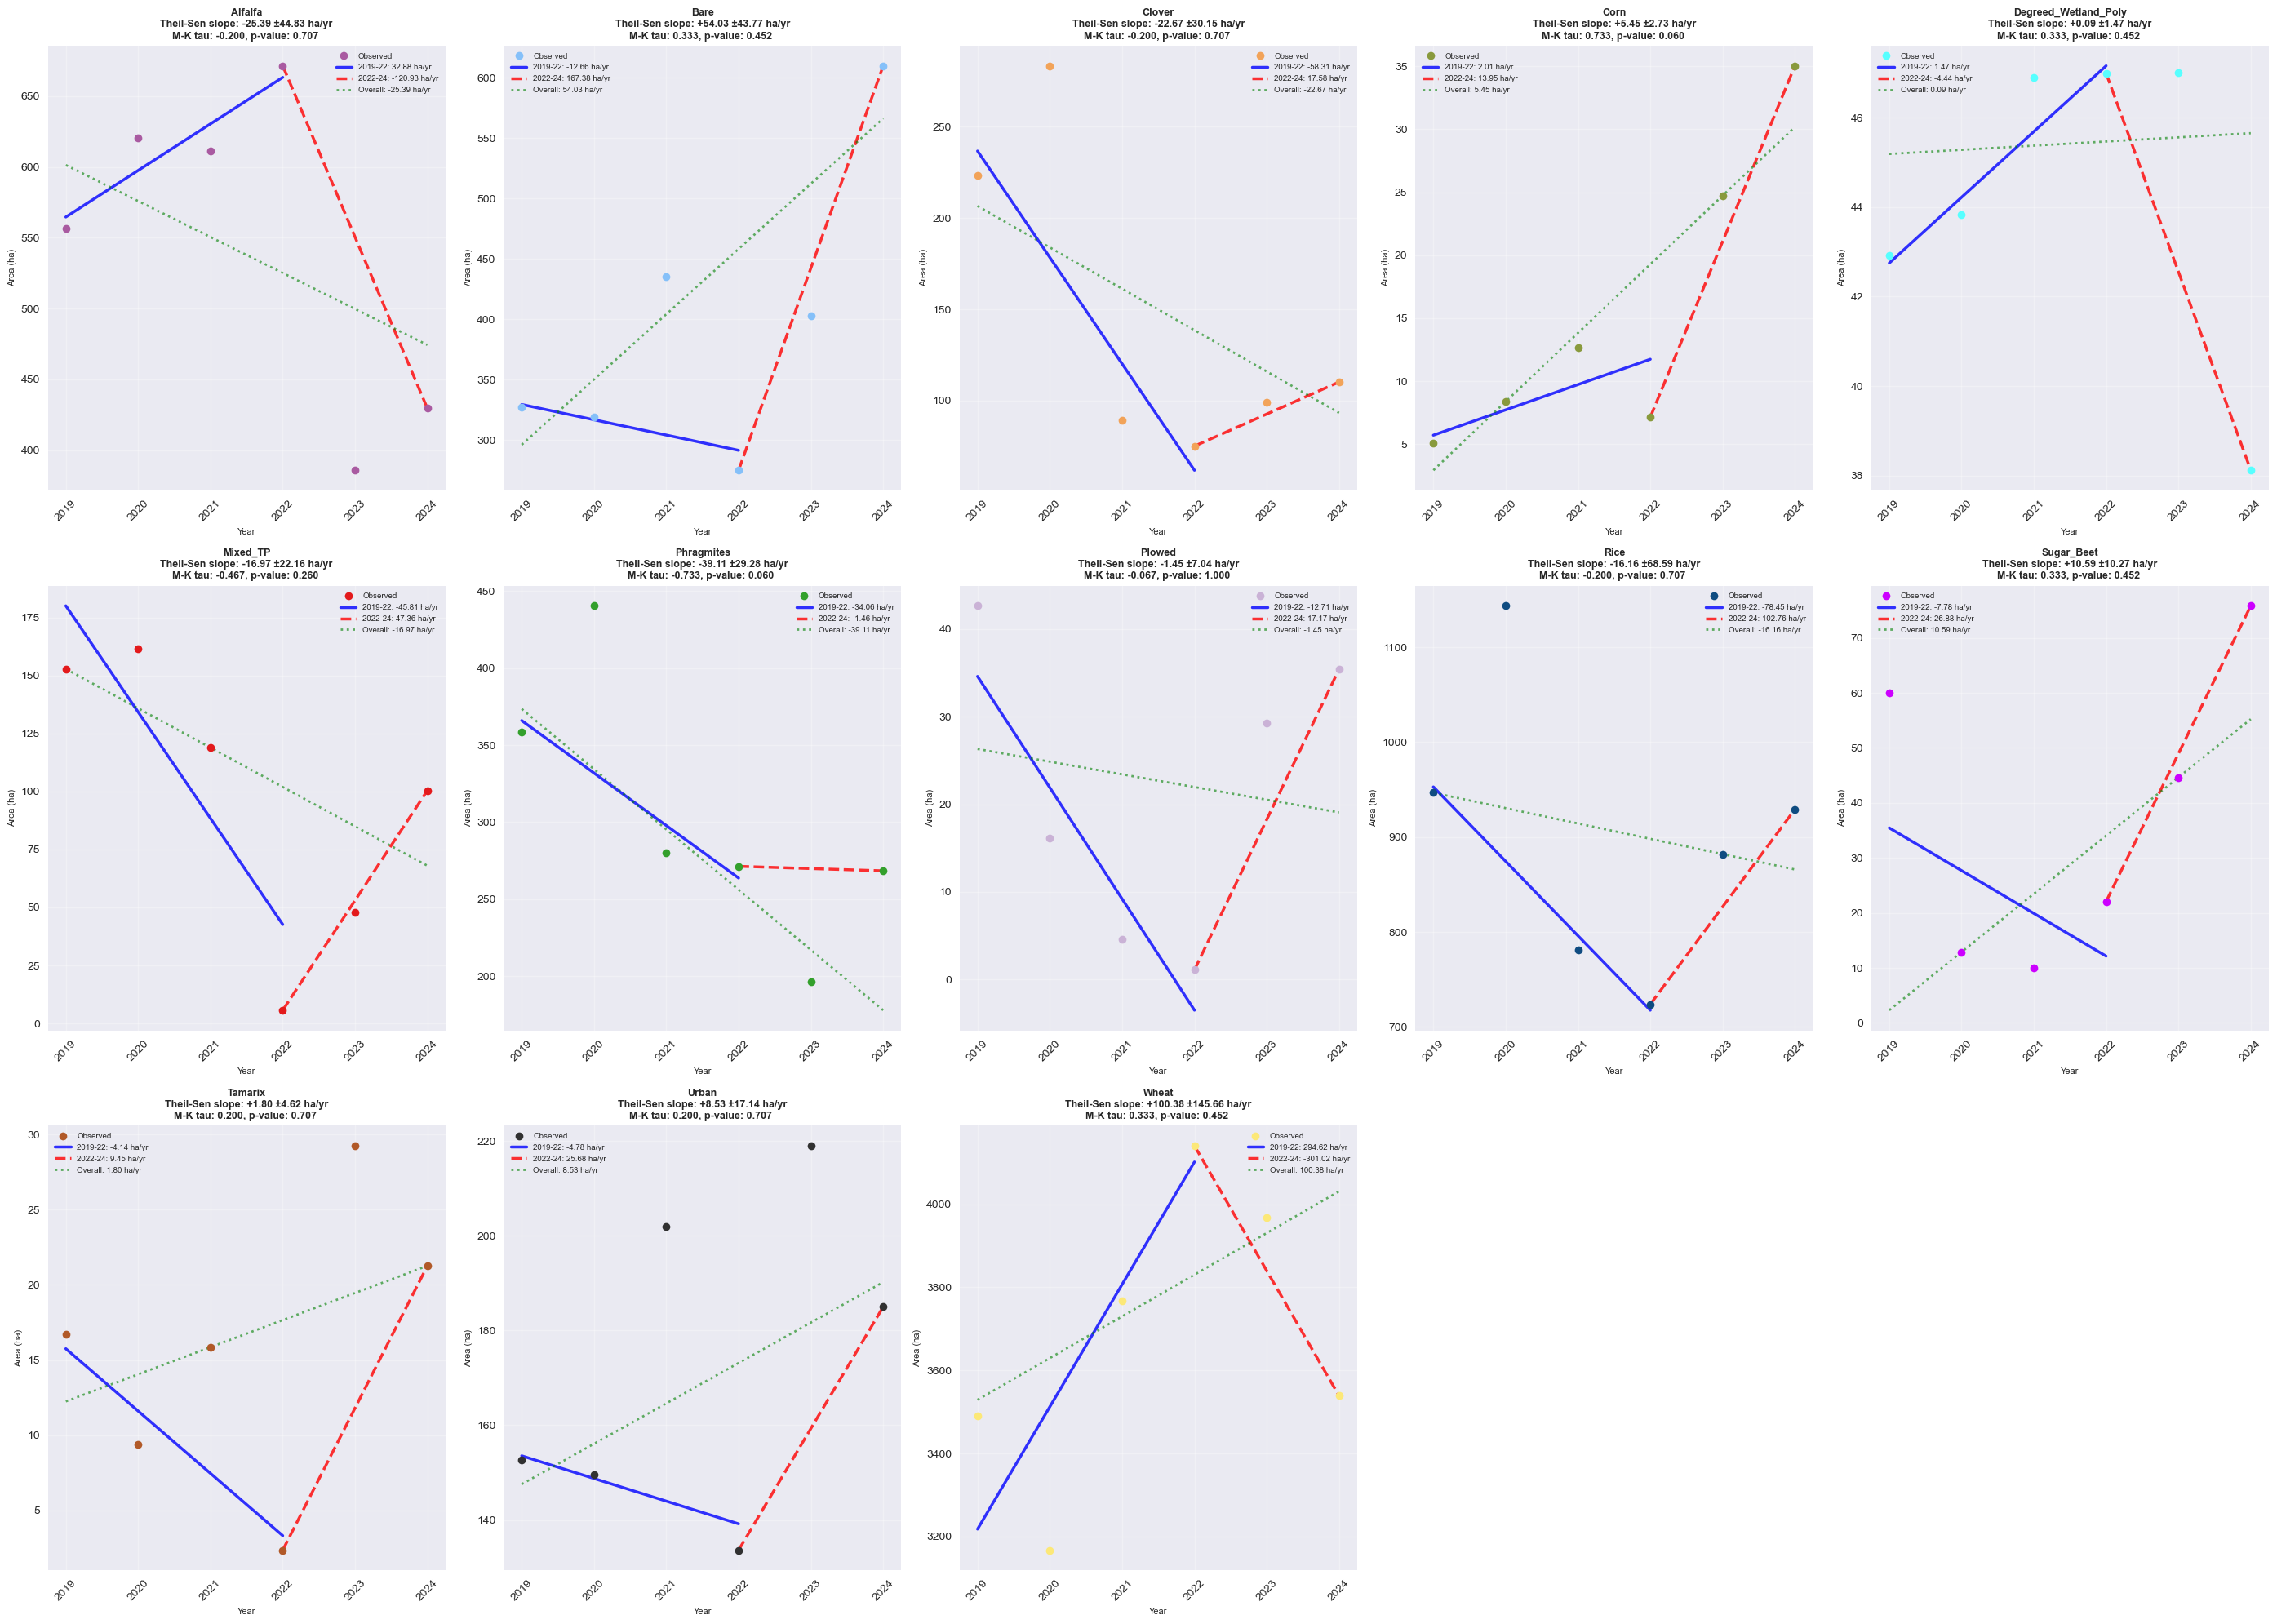


5. HEATMAP VISUALIZATIONS


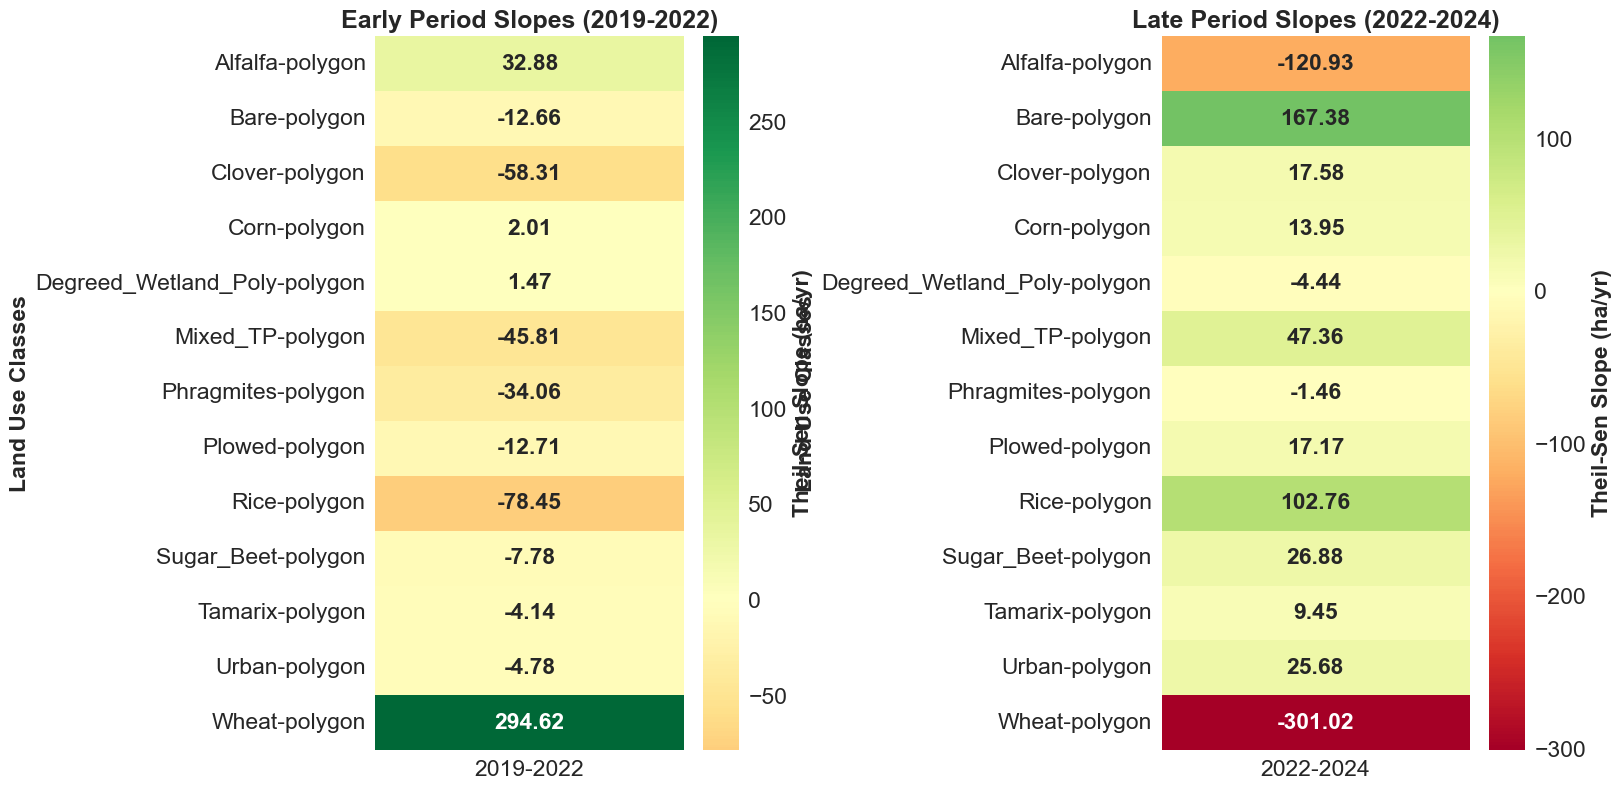

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy import stats
from sklearn.linear_model import LinearRegression, HuberRegressor
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Mann-Kendall test implementation
def mann_kendall_test(x, y):
    """
    Performs Mann-Kendall test for trend detection.
    Returns: tau (Kendall's tau), p_value, trend direction
    """
    n = len(y)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(y[j] - y[i]) * np.sign(x[j] - x[i])
    
    # Calculate variance
    var_s = n * (n - 1) * (2 * n + 5) / 18
    
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # Two-tailed p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    tau = s / (n * (n - 1) / 2)
    
    return tau, p_value, z

# Theil-Sen slope estimation
def theil_sen_slope(x, y):
    """
    Calculates Theil-Sen slope estimate (robust to outliers).
    Returns: slope, intercept, confidence interval
    """
    n = len(x)
    slopes = []
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            if x[j] != x[i]:
                slopes.append((y[j] - y[i]) / (x[j] - x[i]))
    
    slopes = np.array(slopes)
    slope_estimate = np.median(slopes)
    
    # Calculate confidence interval (95%)
    n_slopes = len(slopes)
    z_alpha = 1.96  # 95% CI
    variance = np.var(slopes)
    ci = z_alpha * np.sqrt(variance / n_slopes)
    
    # Intercept calculation
    intercepts = y - slope_estimate * x
    intercept_estimate = np.median(intercepts)
    
    return slope_estimate, intercept_estimate, ci, slopes

# Set up paths and style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
base_path = Path(r"F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict")

# Years to analyze
years = ['2019', '2020', '2021', '2022', '2023', '2024']

# Define class groupings
class_groupings = {
    'Crop': ['Wheat-polygon', 'Rice-polygon', 'Alfalfa-polygon', 'Corn-polygon', 
             'Clover-polygon', 'Sugar_Beet-polygon', 'Plowed-polygon'],
    'Wetland': ['Phragmites-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Tamarix-polygon'],
    'Urban': ['Urban-polygon'],
    'Bare': ['Bare-polygon']
}

# Custom color palette for classes
custom_palette = {
    'Wheat-polygon': "#fce878",  
    'Rice-polygon': '#0f4c81',   
    'Alfalfa-polygon': '#a95aa1',
    'Bare-polygon': '#85c0f9',   
    'Phragmites-polygon': '#33a02c', 
    'Urban-polygon': "#313131",     
    'Clover-polygon': '#f2a359',    
    'Mixed_TP-polygon': '#e31a1c',  
    'Degreed_Wetland_Poly-polygon': "#57ffff", 
    'Tamarix-polygon': '#b15928',              
    'Corn-polygon': "#899a3d",                  
    'Sugar_Beet-polygon': "#cc00ff",            
    'Plowed-polygon': '#cab2d6',                
}

# Group colors
group_colors = {
    'Crop': '#2E8B57',      # SeaGreen
    'Wetland': '#4169E1',   # RoyalBlue
    'Urban': '#DC143C',     # Crimson
    'Bare': '#FF8C00'      # DarkOrange
}

print("="*60)
print("ROBUST LULC TREND ANALYSIS 2019-2024")
print("(Theil-Sen Slope + Mann-Kendall Test)")
print("="*60)

# Function to load data for all years
def load_yearly_data():
    yearly_data = {}
    for year in years:
        try:
            file_path = base_path / f"Predictions_{year}_Enhanced_Seasonal" / "class_areas_summary.csv"
            if file_path.exists():
                df = pd.read_csv(file_path)
                yearly_data[year] = df
                print(f"✓ Loaded data for {year}: {len(df)} classes")
            else:
                print(f"✗ File not found for {year}: {file_path}")
        except Exception as e:
            print(f"✗ Error loading {year}: {e}")
    
    return yearly_data

# Load all data
yearly_data = load_yearly_data()

if not yearly_data:
    print("No data files found. Please check the file paths.")
    exit()

# Combine all years into a single DataFrame
print("\nCombining data...")
combined_data = []

for year, df in yearly_data.items():
    df_copy = df.copy()
    df_copy['Year'] = int(year)
    combined_data.append(df_copy)

df_all = pd.concat(combined_data, ignore_index=True)
print(f"Combined data shape: {df_all.shape}")

# Add group information
def assign_group(class_name):
    for group, classes in class_groupings.items():
        if class_name in classes:
            return group
    return 'Bare'

df_all['Group'] = df_all['Class'].apply(assign_group)

# Create output directory
output_dir = base_path / "Trend_Analysis_2019_2024_Robust"
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir}")

# ============================================================================
# 1. INDIVIDUAL CLASS TRENDS (Theil-Sen + Mann-Kendall + Piecewise)
# ============================================================================
print("\n" + "="*50)
print("1. ROBUST INDIVIDUAL CLASS TREND ANALYSIS")
print("="*50)

fig, axes = plt.subplots(3, 5, figsize=(28, 20))
axes = axes.flatten()

class_trends = {}

for i, class_name in enumerate(sorted(df_all['Class'].unique())):
    if i >= len(axes):
        break
    
    class_data = df_all[df_all['Class'] == class_name].sort_values('Year')
    
    if len(class_data) > 1:
        X = class_data['Year'].values
        y = class_data['Area_Hectares'].values
        
        # Theil-Sen slope
        ts_slope, ts_intercept, ts_ci, all_slopes = theil_sen_slope(X, y)
        
        # Mann-Kendall test
        tau, p_value, z_stat = mann_kendall_test(X, y)
        
        # Split analysis: 2019-2022 and 2022-2024
        mask_early = X <= 2022
        mask_late = X >= 2022
        
        X_early = X[mask_early]
        y_early = y[mask_early]
        X_late = X[mask_late]
        y_late = y[mask_late]
        
        if len(X_early) > 1:
            ts_slope_early, ts_int_early, _, _ = theil_sen_slope(X_early, y_early)
        else:
            ts_slope_early = 0
            ts_int_early = y_early[0] if len(y_early) > 0 else 0
        
        if len(X_late) > 1:
            ts_slope_late, ts_int_late, _, _ = theil_sen_slope(X_late, y_late)
        else:
            ts_slope_late = 0
            ts_int_late = y_late[0] if len(y_late) > 0 else 0
        
        class_trends[class_name] = {
            'theil_sen_slope': ts_slope,
            'theil_sen_ci': ts_ci,
            'mann_kendall_tau': tau,
            'mann_kendall_pvalue': p_value,
            'mann_kendall_zscore': z_stat,
            'trend': 'Increasing' if ts_slope > 0 else 'Decreasing',
            'significance': 'Significant' if p_value < 0.05 else 'Not Significant',
            'slope_early': ts_slope_early,
            'slope_late': ts_slope_late
        }
        
        # Plotting
        ax = axes[i]
        color = custom_palette.get(class_name, 'gray')
        
        # Data points
        ax.plot(X, y, 'o', color=color, markersize=7, label='Observed', zorder=3)
        
        # Early period trend line (2019-2022)
        if len(X_early) > 1:
            X_early_line = np.array([X_early.min(), X_early.max()])
            y_early_line = ts_int_early + ts_slope_early * X_early_line
            ax.plot(X_early_line, y_early_line, '-', color='blue', linewidth=2.5, 
                   alpha=0.8, label=f'2019-22: {ts_slope_early:.2f} ha/yr')
        
        # Late period trend line (2022-2024)
        if len(X_late) > 1:
            X_late_line = np.array([X_late.min(), X_late.max()])
            y_late_line = ts_int_late + ts_slope_late * X_late_line
            ax.plot(X_late_line, y_late_line, '--', color='red', linewidth=2.5, 
                   alpha=0.8, label=f'2022-24: {ts_slope_late:.2f} ha/yr')
        
        # Overall trend line (Theil-Sen)
        X_overall = np.array([X.min(), X.max()])
        y_overall = ts_intercept + ts_slope * X_overall
        ax.plot(X_overall, y_overall, ':', color='green', linewidth=2, 
               alpha=0.6, label=f'Overall: {ts_slope:.2f} ha/yr')
        
        title_str = f'{class_name.replace("-polygon", "")}\n'
        title_str += f'Theil-Sen slope: {ts_slope:+.2f} ±{ts_ci:.2f} ha/yr\n'
        title_str += f'M-K tau: {tau:.3f}, p-value: {p_value:.3f} {"*" if p_value < 0.05 else ""}'
        
        ax.set_title(title_str, fontsize=9, fontweight='bold')
        ax.set_xlabel('Year', fontsize=8)
        ax.set_ylabel('Area (ha)', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='best')
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(output_dir / "individual_class_trends_robust.png", dpi=300, bbox_inches='tight')
plt.show()

# # ============================================================================
# # 2. GROUP-LEVEL ANALYSIS (Robust)
# # ============================================================================
# print("\n" + "="*50)
# print("2. ROBUST GROUP TRENDS")
# print("="*50)

# group_data = df_all.groupby(['Year', 'Group'])['Area_Hectares'].sum().reset_index()

# fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# group_trends = {}
# for i, (group, color) in enumerate(group_colors.items()):
#     row, col = i // 2, i % 2
#     ax = axes[row, col]
    
#     group_subset = group_data[group_data['Group'] == group].sort_values('Year')
    
#     if len(group_subset) > 1:
#         X = group_subset['Year'].values
#         y = group_subset['Area_Hectares'].values
        
#         # Theil-Sen slope
#         ts_slope, ts_intercept, ts_ci, _ = theil_sen_slope(X, y)
        
#         # Mann-Kendall test
#         tau, p_value, z_stat = mann_kendall_test(X, y)
        
#         # Piecewise analysis
#         mask_early = X <= 2022
#         mask_late = X >= 2022
        
#         X_early = X[mask_early]
#         y_early = y[mask_early]
#         X_late = X[mask_late]
#         y_late = y[mask_late]
        
#         if len(X_early) > 1:
#             ts_slope_early, ts_int_early, _, _ = theil_sen_slope(X_early, y_early)
#         else:
#             ts_slope_early = 0
#             ts_int_early = y_early[0] if len(y_early) > 0 else 0
        
#         if len(X_late) > 1:
#             ts_slope_late, ts_int_late, _, _ = theil_sen_slope(X_late, y_late)
#         else:
#             ts_slope_late = 0
#             ts_int_late = y_late[0] if len(y_late) > 0 else 0
        
#         group_trends[group] = {
#             'theil_sen_slope': ts_slope,
#             'mann_kendall_pvalue': p_value,
#             'mann_kendall_tau': tau,
#             'significance': 'Significant' if p_value < 0.05 else 'Not Significant',
#             'slope_early': ts_slope_early,
#             'slope_late': ts_slope_late
#         }
        
#         # Plot
#         ax.plot(X, y, 'o', color=color, markersize=9, label='Observed', zorder=3)
        
#         # Early period
#         if len(X_early) > 1:
#             X_early_line = np.array([X_early.min(), X_early.max()])
#             y_early_line = ts_int_early + ts_slope_early * X_early_line
#             ax.plot(X_early_line, y_early_line, '-', color='blue', linewidth=3, 
#                    alpha=0.7, label=f'2019-22: {ts_slope_early:+.1f} ha/yr')
        
#         # Late period
#         if len(X_late) > 1:
#             X_late_line = np.array([X_late.min(), X_late.max()])
#             y_late_line = ts_int_late + ts_slope_late * X_late_line
#             ax.plot(X_late_line, y_late_line, '--', color='red', linewidth=3, 
#                    alpha=0.7, label=f'2022-24: {ts_slope_late:+.1f} ha/yr')
        
#         # Overall trend
#         X_overall = np.array([X.min(), X.max()])
#         y_overall = ts_intercept + ts_slope * X_overall
#         ax.plot(X_overall, y_overall, ':', color='green', linewidth=2.5, 
#                alpha=0.6, label=f'Overall: {ts_slope:+.1f} ha/yr')
        
#         ax.set_title(f'{group} Land Use\n'
#                     f'Theil-Sen: {ts_slope:+.1f} ha/yr | M-K tau: {tau:.3f}, p={p_value:.3f} '
#                     f'{"*" if p_value < 0.05 else ""}',
#                     fontsize=12, fontweight='bold')
#         ax.set_xlabel('Year', fontsize=10)
#         ax.set_ylabel('Area (hectares)', fontsize=10)
#         ax.grid(True, alpha=0.3)
#         ax.legend(fontsize=9, loc='best')
        
#         # Percentage change annotation
#         if len(group_subset) >= 2:
#             start_area = group_subset.iloc[0]['Area_Hectares']
#             end_area = group_subset.iloc[-1]['Area_Hectares']
#             pct_change = ((end_area - start_area) / start_area) * 100 if start_area > 0 else 0
#             ax.text(0.05, 0.95, f'Total change: {pct_change:+.1f}%', 
#                    transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
#                    fontsize=10)

# plt.tight_layout()
# plt.savefig(output_dir / "group_trends_robust.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # 3. COMPARATIVE ANALYSIS PLOTS
# # ============================================================================
# print("\n" + "="*50)
# print("3. COMPARATIVE VISUALIZATIONS")
# print("="*50)

# # 3.1 Stacked Area Chart
# plt.figure(figsize=(14, 8))
# pivot_data = group_data.pivot(index='Year', columns='Group', values='Area_Hectares').fillna(0)

# plt.stackplot(pivot_data.index, 
#               pivot_data['Crop'], 
#               pivot_data['Wetland'], 
#               pivot_data['Urban'], 
#               pivot_data['Bare'],
#               labels=['Crop', 'Wetland', 'Urban', 'Bare'],
#               colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Bare']],
#               alpha=0.8)

# plt.title('Land Use Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
# plt.xlabel('Year')
# plt.ylabel('Area (hectares)')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(output_dir / "stacked_area_chart.png", dpi=300, bbox_inches='tight')
# plt.show()

# # 3.2 Percentage Composition
# plt.figure(figsize=(14, 8))
# pivot_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

# plt.stackplot(pivot_pct.index, 
#               pivot_pct['Crop'], 
#               pivot_pct['Wetland'], 
#               pivot_pct['Urban'], 
#               pivot_pct['Bare'],
#               labels=['Crop', 'Wetland', 'Urban', 'Bare'],
#               colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Bare']],
#               alpha=0.8)

# plt.title('Land Use Percentage Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
# plt.xlabel('Year')
# plt.ylabel('Percentage (%)')
# plt.ylim(0, 100)
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(output_dir / "percentage_composition.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # 4. STATISTICAL SUMMARY
# # ============================================================================
# print("\n" + "="*50)
# print("4. ROBUST STATISTICAL SUMMARY")
# print("="*50)

# # Create comprehensive summary tables
# individual_summary = pd.DataFrame(class_trends).T
# individual_summary = individual_summary.round(4)

# group_summary = pd.DataFrame(group_trends).T
# group_summary = group_summary.round(4)

# print("\nIndividual Class Trends (Theil-Sen + Mann-Kendall):")
# print("=" * 80)
# print(individual_summary[['theil_sen_slope', 'mann_kendall_tau', 'mann_kendall_pvalue', 
#                          'slope_early', 'slope_late']])

# print("\n\nGroup Trends (Theil-Sen + Mann-Kendall):")
# print("=" * 60)
# print(group_summary[['theil_sen_slope', 'mann_kendall_tau', 'mann_kendall_pvalue',
#                      'slope_early', 'slope_late']])

# # Save summaries
# individual_summary.to_csv(output_dir / "individual_class_trends_robust_summary.csv")
# group_summary.to_csv(output_dir / "group_trends_robust_summary.csv")

# ============================================================================
# 5. HEATMAP OF THEIL-SEN SLOPES
# ============================================================================
print("\n" + "="*50)
print("5. HEATMAP VISUALIZATIONS")
print("="*50)

# Create heatmap of piecewise slopes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Early period slopes
early_slopes = {k: v['slope_early'] for k, v in class_trends.items()}
late_slopes = {k: v['slope_late'] for k, v in class_trends.items()}

early_df = pd.DataFrame([early_slopes]).T
early_df.columns = ['2019-2022']

late_df = pd.DataFrame([late_slopes]).T
late_df.columns = ['2022-2024']

# Heatmap 1: Early Period with larger fonts
sns.heatmap(early_df, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            cbar_kws={'label': 'Theil-Sen Slope (ha/yr)'},
            annot_kws={'size': 16.5, 'weight': 'bold'},  # Larger annotation numbers
            ax=axes[0])
axes[0].set_title('Early Period Slopes (2019-2022)', fontweight='bold', fontsize=18)  # 12 * 1.5 = 18
axes[0].set_ylabel('Land Use Classes', fontsize=16.5, fontweight='bold')  # 11 * 1.5 = 16.5
axes[0].tick_params(axis='x', labelsize=16.5)  # 11 * 1.5 = 16.5
axes[0].tick_params(axis='y', labelsize=16.5)  # 11 * 1.5 = 16.5

# Heatmap 2: Late Period with larger fonts
sns.heatmap(late_df, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            cbar_kws={'label': 'Theil-Sen Slope (ha/yr)'},
            annot_kws={'size': 16.5, 'weight': 'bold'},  # Larger annotation numbers
            ax=axes[1])
axes[1].set_title('Late Period Slopes (2022-2024)', fontweight='bold', fontsize=18)  # 12 * 1.5 = 18
axes[1].set_ylabel('Land Use Classes', fontsize=16.5, fontweight='bold')  # 11 * 1.5 = 16.5
axes[1].tick_params(axis='x', labelsize=16.5)  # 11 * 1.5 = 16.5
axes[1].tick_params(axis='y', labelsize=16.5)  # 11 * 1.5 = 16.5

# Set colorbar label size separately
for ax in axes:
    cbar = ax.collections[0].colorbar
    if cbar:
        cbar.set_label('Theil-Sen Slope (ha/yr)', size=16.5, weight='bold')
        cbar.ax.tick_params(labelsize=16.5)

plt.tight_layout()
plt.savefig(output_dir / "theil_sen_slopes_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# # ============================================================================
# # 6. MANN-KENDALL SIGNIFICANCE PLOT
# # ============================================================================
# print("\n" + "="*50)
# print("6. MANN-KENDALL SIGNIFICANCE PLOT")
# print("="*50)

# fig, ax = plt.subplots(figsize=(14, 8))

# classes_sorted = sorted(class_trends.keys(), 
#                        key=lambda x: class_trends[x]['mann_kendall_pvalue'])
# pvalues = [class_trends[c]['mann_kendall_pvalue'] for c in classes_sorted]
# slopes = [class_trends[c]['theil_sen_slope'] for c in classes_sorted]
# colors_plot = [custom_palette.get(c, 'gray') for c in classes_sorted]

# # Color code by significance
# bar_colors = ['red' if p < 0.05 else 'gray' for p in pvalues]

# ax.barh(range(len(classes_sorted)), pvalues, color=bar_colors, alpha=0.7)
# ax.axvline(x=0.05, color='black', linestyle='--', linewidth=2, label='α = 0.05')
# ax.set_yticks(range(len(classes_sorted)))
# ax.set_yticklabels([c.replace('-polygon', '') for c in classes_sorted])
# ax.set_xlabel('p-value (Mann-Kendall)', fontsize=11)
# ax.set_title('Mann-Kendall Trend Significance Test\n(Red = Significant at α=0.05)',
#             fontsize=13, fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3, axis='x')

# plt.tight_layout()
# plt.savefig(output_dir / "mann_kendall_significance.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # 7. SUMMARY REPORT
# # ============================================================================
# print("\n" + "="*50)
# print("7. GENERATING ROBUST SUMMARY REPORT")
# print("="*50)

# report = []
# report.append("ROBUST LULC TREND ANALYSIS REPORT (2019-2024)")
# report.append("Using Theil-Sen Slope and Mann-Kendall Test")
# report.append("=" * 70)
# report.append("")

# report.append("METHODOLOGY:")
# report.append("-" * 35)
# report.append("• Theil-Sen slope: Robust, non-parametric slope estimator")
# report.append("• Mann-Kendall test: Non-parametric trend significance test")
# report.append("• Piecewise analysis: Separate trends for 2019-2022 and 2022-2024")
# report.append("")

# report.append("GROUP TREND SUMMARY:")
# report.append("-" * 40)
# for group, stats in sorted(group_trends.items()):
#     sig_marker = "***" if stats['mann_kendall_pvalue'] < 0.05 else ""
#     report.append(f"{group}:")
#     report.append(f"  Overall Theil-Sen slope: {stats['theil_sen_slope']:+.2f} ha/yr")
#     report.append(f"  2019-2022 slope: {stats['slope_early']:+.2f} ha/yr")
#     report.append(f"  2022-2024 slope: {stats['slope_late']:+.2f} ha/yr")
#     report.append(f"  Mann-Kendall tau: {stats['mann_kendall_tau']:.4f}")
#     report.append(f"  p-value: {stats['mann_kendall_pvalue']:.4f} {sig_marker}")
#     report.append(f"  Trend: {stats['significance']}")
#     report.append("")

# report.append("SIGNIFICANT INDIVIDUAL CLASS TRENDS (p < 0.05):")
# report.append("-" * 50)
# significant_trends = [(k, v) for k, v in class_trends.items() 
#                      if v['mann_kendall_pvalue'] < 0.05]
# if significant_trends:
#     for class_name, stats in sorted(significant_trends, 
#                                    key=lambda x: x[1]['mann_kendall_pvalue']):
#         report.append(f"{class_name}:")
#         report.append(f"  Theil-Sen slope: {stats['theil_sen_slope']:+.2f} ha/yr "
#                      f"(95% CI: ±{stats['theil_sen_ci']:.2f})")
#         report.append(f"  2019-2022 slope: {stats['slope_early']:+.2f} ha/yr")
#         report.append(f"  2022-2024 slope: {stats['slope_late']:+.2f} ha/yr")
#         report.append(f"  Mann-Kendall tau: {stats['mann_kendall_tau']:.4f}")
#         report.append(f"  p-value: {stats['mann_kendall_pvalue']:.4f}")
#         report.append(f"  Direction: {stats['trend']}")
#         report.append("")
# else:
#     report.append("No classes with statistically significant trends (p < 0.05)")
#     report.append("")

# # Save report
# report_text = '\n'.join(report)
# with open(output_dir / "robust_trend_analysis_report.txt", 'w') as f:
#     f.write(report_text)

# print(report_text)

# print("\n" + "="*70)
# print("ROBUST ANALYSIS COMPLETE!")
# print("="*70)
# print(f"All outputs saved to: {output_dir}")
# print("\nGenerated files:")
# print("✓ individual_class_trends_robust.png")
# print("✓ group_trends_robust.png")
# print("✓ stacked_area_chart.png")
# print("✓ percentage_composition.png")
# print("✓ theil_sen_slopes_heatmap.png")
# print("✓ mann_kendall_significance.png")
# print("✓ individual_class_trends_robust_summary.csv")
# print("✓ group_trends_robust_summary.csv")
# print("✓ robust_trend_analysis_report.txt")

In [6]:
# # Just to create 2024 Area CSV 

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import geopandas as gpd
# from pathlib import Path
# import warnings
# from scipy import stats
# from sklearn.linear_model import LinearRegression
# from shapely import wkt
# import json
# warnings.filterwarnings('ignore')

# # Set up paths and style
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")
# base_path = Path(r"F:\_____My_Thesies____")

# # 2024 specific paths
# enhanced_2024_path = base_path / "Implimantation" / "3.Train_Model" / "6.Adding_Phenology" / "Enhanced_Classification_Results_50-50" / "final_dataset_enhanced_all.csv"
# seg_2024_path = base_path / "_ImpFiles" / "3. Feature Selection" / "_Sentinel Data" / "2. Divided Data" / "6.Segmentation" / "Seg_2024" / "segmentation_layer.shp"

# # Output path for 2024
# output_2024_dir = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Predictions_2024_Enhanced_Seasonal"
# output_2024_dir.mkdir(parents=True, exist_ok=True)

# # Trend analysis output
# trend_output_dir = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Trend_Analysis_2019_2024"
# trend_output_dir.mkdir(parents=True, exist_ok=True)

# # Custom color palette
# custom_palette = {
#     'Wheat-polygon': "#fce878",  
#     'Rice-polygon': '#0f4c81',   
#     'Alfalfa-polygon': '#a95aa1',
#     'Bare-polygon': '#85c0f9',   
#     'Phragmites-polygon': '#33a02c', 
#     'Urban-polygon': "#313131",     
#     'Clover-polygon': '#f2a359',    
#     'Mixed_TP-polygon': '#e31a1c',  
#     'Degreed_Wetland_Poly-polygon': "#57ffff", 
#     'Tamarix-polygon': '#b15928',              
#     'Corn-polygon': "#899a3d",                  
#     'Sugar_Beet-polygon': "#cc00ff",            
#     'Plowed-polygon': '#cab2d6',                
# }

# # Define class groupings
# class_groupings = {
#     'Crop': ['Wheat-polygon', 'Rice-polygon', 'Alfalfa-polygon', 'Corn-polygon', 
#              'Clover-polygon', 'Sugar_Beet-polygon', 'Plowed-polygon'],
#     'Wetland': ['Phragmites-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon'],
#     'Urban': ['Urban-polygon'],
#     'Other': ['Bare-polygon', 'Tamarix-polygon']
# }

# # Group colors
# group_colors = {
#     'Crop': '#2E8B57',      # SeaGreen
#     'Wetland': '#4169E1',   # RoyalBlue
#     'Urban': '#DC143C',     # Crimson
#     'Other': '#FF8C00'      # DarkOrange
# }

# print("="*60)
# print("PROCESSING 2024 DATA AND TREND ANALYSIS")
# print("="*60)

# # ============================================================================
# # STEP 1: PROCESS 2024 DATA
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 1: PROCESSING 2024 DATA")
# print("="*50)

# print("Loading 2024 enhanced dataset...")
# df_2024 = pd.read_csv(enhanced_2024_path)
# print(f"2024 data shape: {df_2024.shape}")
# print(f"2024 columns: {list(df_2024.columns)}")

# print("\nLoading 2024 segmentation layer...")
# gdf_seg_2024 = gpd.read_file(seg_2024_path)
# print(f"2024 segmentation shape: {gdf_seg_2024.shape}")
# print(f"2024 segmentation columns: {list(gdf_seg_2024.columns)}")

# # Handle geometry column in 2024 data
# if 'geometry' in df_2024.columns:
#     print("Found geometry column in 2024 data, processing...")
    
#     # Check if geometries are stored as text
#     sample_geom = df_2024['geometry'].dropna().iloc[0] if not df_2024['geometry'].dropna().empty else None
    
#     if sample_geom and isinstance(sample_geom, str):
#         print("Converting WKT strings to shapely objects...")
#         def safe_wkt_loads(geom_str):
#             if pd.isna(geom_str) or geom_str == '':
#                 return None
#             try:
#                 return wkt.loads(geom_str)
#             except:
#                 return None
        
#         df_2024['geometry'] = df_2024['geometry'].apply(safe_wkt_loads)
    
#     # Create GeoDataFrame
#     try:
#         gdf_2024 = gpd.GeoDataFrame(df_2024, geometry='geometry')
#         missing_geom = gdf_2024['geometry'].isna().sum()
#         print(f"Missing geometries in 2024 data: {missing_geom}")
#     except Exception as e:
#         print(f"Error creating GeoDataFrame: {e}")
#         gdf_2024 = df_2024.copy()
#         missing_geom = len(df_2024)
# else:
#     print("No geometry column found in 2024 data")
#     gdf_2024 = df_2024.copy()
#     missing_geom = len(df_2024)

# # Merge with segmentation data if needed
# if missing_geom > 0 and 'PXLVAL' in df_2024.columns and 'PXLVAL' in gdf_seg_2024.columns:
#     print("Merging with segmentation data to fill missing geometries...")
    
#     gdf_merged = gdf_2024.merge(
#         gdf_seg_2024[['PXLVAL', 'geometry']], 
#         on='PXLVAL', 
#         how='left', 
#         suffixes=('', '_seg')
#     )
    
#     # Fill missing geometries
#     if 'geometry' in gdf_merged.columns and 'geometry_seg' in gdf_merged.columns:
#         mask = gdf_merged['geometry'].isna()
#         gdf_merged.loc[mask, 'geometry'] = gdf_merged.loc[mask, 'geometry_seg']
#         gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
#     elif 'geometry_seg' in gdf_merged.columns:
#         gdf_merged['geometry'] = gdf_merged['geometry_seg']
#         gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
    
#     # Create final GeoDataFrame
#     try:
#         gdf_2024_final = gpd.GeoDataFrame(gdf_merged, geometry='geometry', crs=gdf_seg_2024.crs)
#         final_missing_geom = gdf_2024_final['geometry'].isna().sum()
#         print(f"Remaining missing geometries: {final_missing_geom}")
#     except Exception as e:
#         print(f"Error creating final GeoDataFrame: {e}")
#         gdf_2024_final = gdf_2024.copy()
# else:
#     gdf_2024_final = gdf_2024.copy()

# # Identify prediction column for 2024
# pred_cols_2024 = [col for col in gdf_2024_final.columns if 'pred' in col.lower() or 'layer' in col.lower()]
# print(f"Potential prediction columns: {pred_cols_2024}")

# # Use predicted_layer or layer column
# if 'predicted_layer' in gdf_2024_final.columns:
#     pred_col_2024 = 'predicted_layer'
# elif 'layer' in gdf_2024_final.columns:
#     pred_col_2024 = 'layer'
# else:
#     pred_col_2024 = pred_cols_2024[0] if pred_cols_2024 else None

# print(f"Using prediction column: {pred_col_2024}")

# # Calculate areas for 2024
# if pred_col_2024 and 'geometry' in gdf_2024_final.columns:
#     print("\nCalculating areas for 2024...")
    
#     # Check and transform CRS if needed
#     if gdf_2024_final.crs and gdf_2024_final.crs.is_geographic:
#         print("Converting from geographic to projected CRS for area calculation...")
#         gdf_2024_proj = gdf_2024_final.to_crs('EPSG:32639')  # UTM Zone 39N
#         area_gdf = gdf_2024_proj
#     else:
#         area_gdf = gdf_2024_final
    
#     # Calculate areas
#     area_gdf_clean = area_gdf.dropna(subset=[pred_col_2024, 'geometry']).copy()
#     area_gdf_clean['area_m2'] = area_gdf_clean.geometry.area
#     area_gdf_clean['area_ha'] = area_gdf_clean['area_m2'] / 10000
    
#     # Group by class and sum areas
#     class_areas_2024 = area_gdf_clean.groupby(pred_col_2024)['area_ha'].sum().sort_values(ascending=False)
    
#     print("2024 Class Areas (Hectares):")
#     print("-" * 30)
#     total_area = 0
#     for class_val, area in class_areas_2024.items():
#         print(f"Class {class_val}: {area:.2f} ha")
#         total_area += area
#     print(f"\nTotal Area 2024: {total_area:.2f} ha")
    
#     # Create 2024 class areas summary CSV
#     class_areas_2024_df = pd.DataFrame({
#         'Class': class_areas_2024.index,
#         'Area_Hectares': class_areas_2024.values,
#         'Percentage': (class_areas_2024.values / class_areas_2024.sum() * 100)
#     })
    
#     # Save 2024 class areas
#     class_areas_2024_path = output_2024_dir / "class_areas_summary.csv"
#     class_areas_2024_df.to_csv(class_areas_2024_path, index=False)
#     print(f"2024 class areas saved to: {class_areas_2024_path}")
    
#     # Save processed 2024 data
#     processed_2024_shp = output_2024_dir / "predictions_2024_with_geometry.shp"
#     gdf_2024_final.to_file(processed_2024_shp)
#     print(f"2024 processed data saved to: {processed_2024_shp}")

# else:
#     print("Cannot calculate areas for 2024 - missing geometry or prediction column")

# # ============================================================================
# # STEP 2: LOAD ALL YEARS DATA FOR TREND ANALYSIS
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 2: LOADING ALL YEARS FOR TREND ANALYSIS")
# print("="*50)

# years = ['2019', '2020', '2021', '2022', '2023', '2024']
# yearly_data = {}

# # Load data for 2019-2023 from existing files
# predict_base_path = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict"

# for year in years[:-1]:  # 2019-2023
#     try:
#         file_path = predict_base_path / f"Predictions_{year}_Enhanced_Seasonal" / "class_areas_summary.csv"
#         if file_path.exists():
#             df = pd.read_csv(file_path)
#             yearly_data[year] = df
#             print(f"✓ Loaded data for {year}: {len(df)} classes")
#         else:
#             print(f"✗ File not found for {year}: {file_path}")
#     except Exception as e:
#         print(f"✗ Error loading {year}: {e}")

# # Add 2024 data
# if 'class_areas_2024_df' in locals():
#     yearly_data['2024'] = class_areas_2024_df
#     print(f"✓ Added 2024 data: {len(class_areas_2024_df)} classes")

# print(f"\nTotal years loaded: {len(yearly_data)}")

# if len(yearly_data) < 2:
#     print("Need at least 2 years of data for trend analysis")
#     exit()

# # ============================================================================
# # STEP 3: TREND ANALYSIS
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 3: PERFORMING TREND ANALYSIS")
# print("="*50)

# # Combine all years into a single DataFrame
# combined_data = []
# for year, df in yearly_data.items():
#     df_copy = df.copy()
#     df_copy['Year'] = int(year)
#     combined_data.append(df_copy)

# df_all = pd.concat(combined_data, ignore_index=True)
# print(f"Combined data shape: {df_all.shape}")

# # Add group information
# def assign_group(class_name):
#     for group, classes in class_groupings.items():
#         if class_name in classes:
#             return group
#     return 'Other'

# df_all['Group'] = df_all['Class'].apply(assign_group)

# # ============================================================================
# # VISUALIZATION 1: INDIVIDUAL CLASS TRENDS
# # ============================================================================
# print("Creating individual class trend visualizations...")

# fig, axes = plt.subplots(3, 5, figsize=(25, 18))
# axes = axes.flatten()

# class_trends = {}
# available_years = sorted(df_all['Year'].unique())

# for i, class_name in enumerate(sorted(df_all['Class'].unique())):
#     if i >= len(axes):
#         break
    
#     class_data = df_all[df_all['Class'] == class_name].sort_values('Year')
    
#     if len(class_data) > 1:
#         # Linear regression for trend
#         X = class_data['Year'].values.reshape(-1, 1)
#         y = class_data['Area_Hectares'].values
        
#         reg = LinearRegression().fit(X, y)
#         slope, intercept, r_value, p_value, std_err = stats.linregress(
#             class_data['Year'], class_data['Area_Hectares']
#         )
        
#         class_trends[class_name] = {
#             'slope': slope,
#             'r_squared': r_value**2,
#             'p_value': p_value,
#             'trend': 'Increasing' if slope > 0 else 'Decreasing',
#             'significance': 'Significant' if p_value < 0.05 else 'Not Significant'
#         }
        
#         # Plot
#         ax = axes[i]
#         color = custom_palette.get(class_name, 'gray')
        
#         ax.plot(class_data['Year'], class_data['Area_Hectares'], 
#                 'o-', color=color, linewidth=2, markersize=6)
        
#         # Add trend line
#         trend_y = reg.predict(X)
#         ax.plot(class_data['Year'], trend_y, '--', color='red', alpha=0.7, linewidth=1)
        
#         ax.set_title(f'{class_name.replace("-polygon", "")}\n'
#                     f'Slope: {slope:.2f} ha/year, R²: {r_value**2:.3f}\n'
#                     f'p-value: {p_value:.3f}', fontsize=10)
#         ax.set_xlabel('Year')
#         ax.set_ylabel('Area (ha)')
#         ax.grid(True, alpha=0.3)
#         ax.set_xticks(available_years)

# # Remove empty subplots
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle('Individual LULC Class Trends (2019-2024)', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.savefig(trend_output_dir / "individual_class_trends.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # VISUALIZATION 2: GROUP-LEVEL ANALYSIS
# # ============================================================================
# print("Creating group-level trend analysis...")

# # Aggregate by groups
# group_data = df_all.groupby(['Year', 'Group'])['Area_Hectares'].sum().reset_index()

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# group_trends = {}

# for i, (group, color) in enumerate(group_colors.items()):
#     row, col = i // 2, i % 2
#     ax = axes[row, col]
    
#     group_subset = group_data[group_data['Group'] == group].sort_values('Year')
    
#     if len(group_subset) > 1:
#         # Calculate trend
#         X = group_subset['Year'].values.reshape(-1, 1)
#         y = group_subset['Area_Hectares'].values
        
#         reg = LinearRegression().fit(X, y)
#         slope, intercept, r_value, p_value, std_err = stats.linregress(
#             group_subset['Year'], group_subset['Area_Hectares']
#         )
        
#         group_trends[group] = {
#             'slope': slope,
#             'r_squared': r_value**2,
#             'p_value': p_value,
#             'trend': 'Increasing' if slope > 0 else 'Decreasing'
#         }
        
#         # Plot
#         ax.plot(group_subset['Year'], group_subset['Area_Hectares'], 
#                 'o-', color=color, linewidth=3, markersize=8, label=group)
        
#         # Add trend line
#         trend_y = reg.predict(X)
#         ax.plot(group_subset['Year'], trend_y, '--', color='black', alpha=0.7, linewidth=2)
        
#         ax.set_title(f'{group} Land Use\n'
#                     f'Trend: {slope:.2f} ha/year, R²: {r_value**2:.3f}\n'
#                     f'p-value: {p_value:.3f}', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Year')
#         ax.set_ylabel('Area (hectares)')
#         ax.grid(True, alpha=0.3)
#         ax.set_xticks(available_years)
        
#         # Add percentage change
#         if len(group_subset) >= 2:
#             start_area = group_subset.iloc[0]['Area_Hectares']
#             end_area = group_subset.iloc[-1]['Area_Hectares']
#             pct_change = ((end_area - start_area) / start_area) * 100 if start_area > 0 else 0
#             ax.text(0.05, 0.95, f'Change: {pct_change:+.1f}%', 
#                    transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.suptitle('Land Use Group Trends (2019-2024)', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.savefig(trend_output_dir / "group_trends.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # VISUALIZATION 3: STACKED AREA CHART
# # ============================================================================
# print("Creating stacked area chart...")

# plt.figure(figsize=(14, 8))
# pivot_data = group_data.pivot(index='Year', columns='Group', values='Area_Hectares').fillna(0)

# plt.stackplot(pivot_data.index, 
#               pivot_data['Crop'], 
#               pivot_data['Wetland'], 
#               pivot_data['Urban'], 
#               pivot_data['Other'],
#               labels=['Crop', 'Wetland', 'Urban', 'Other'],
#               colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Other']],
#               alpha=0.8)

# plt.title('Land Use Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
# plt.xlabel('Year')
# plt.ylabel('Area (hectares)')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True, alpha=0.3)
# plt.xticks(available_years)
# plt.tight_layout()
# plt.savefig(trend_output_dir / "stacked_area_chart.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # STATISTICAL SUMMARY AND REPORT
# # ============================================================================
# print("Generating statistical summary...")

# # Create comprehensive summary tables
# if class_trends:
#     individual_summary = pd.DataFrame(class_trends).T
#     individual_summary = individual_summary.round(4)
#     individual_summary.to_csv(trend_output_dir / "individual_class_trends_summary.csv")

# if group_trends:
#     group_summary = pd.DataFrame(group_trends).T
#     group_summary = group_summary.round(4)
#     group_summary.to_csv(trend_output_dir / "group_trends_summary.csv")

# # Generate report
# report = []
# report.append("LULC TREND ANALYSIS REPORT (2019-2024)")
# report.append("=" * 50)
# report.append("")
# report.append(f"Analysis includes {len(yearly_data)} years: {', '.join(yearly_data.keys())}")
# report.append("")

# # Overall statistics
# total_area_by_year = df_all.groupby('Year')['Area_Hectares'].sum()
# report.append("OVERALL STATISTICS:")
# report.append("-" * 20)
# for year in available_years:
#     if year in total_area_by_year.index:
#         report.append(f"{year}: {total_area_by_year[year]:.2f} hectares")

# report.append("")
# report.append("GROUP TREND SUMMARY:")
# report.append("-" * 25)
# for group, stats in group_trends.items():
#     report.append(f"{group}:")
#     report.append(f"  - Annual change: {stats['slope']:+.2f} ha/year")
#     report.append(f"  - R-squared: {stats['r_squared']:.3f}")
#     report.append(f"  - Trend: {stats['trend']}")
#     report.append(f"  - P-value: {stats['p_value']:.3f}")
#     report.append("")

# # Save report
# with open(trend_output_dir / "trend_analysis_report.txt", 'w') as f:
#     f.write('\n'.join(report))

# print('\n'.join(report))

# print("\n" + "="*60)
# print("ANALYSIS COMPLETE!")
# print("="*60)
# print(f"2024 results saved to: {output_2024_dir}")
# print(f"Trend analysis saved to: {trend_output_dir}")
# print("\nGenerated files:")
# print("- 2024 class_areas_summary.csv")
# print("- 2024 predictions_2024_with_geometry.shp")
# print("- individual_class_trends.png")
# print("- group_trends.png") 
# print("- stacked_area_chart.png")
# print("- individual_class_trends_summary.csv")
# print("- group_trends_summary.csv")
# print("- trend_analysis_report.txt")